# Transmitting a digitally modulated signal

The goal of this notebook is to integrate the building blocks for the transmitter and send a digitally modulated signal over the audio channel.

In [1]:
import numpy as np
import sounddevice as sd

# Matplotlib is a plotting library for creating static, animated, and interactive visualizations in Python. The 'inline' magic command allows the plots to be displayed directly in the notebook.
import matplotlib.pyplot as plt
%matplotlib inline

# tweak the appearance of the plots
plt.rcParams['figure.figsize'] = (10, 6)  # Set the default figure size for plots

# seaborn is a statistical data visualization library based on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.
import seaborn as sns
# Set the context for Seaborn plots to 'talk', which is suitable for presentations and larger text sizes.
sns_context = 'talk' 
sns.set_theme(context=sns_context, style="ticks", palette="deep")


In [2]:
# import our modules
from dc_632_26.sources import RandomBitSource
from dc_632_26.freq_shift import Upconverter

## Transmitter block

Integrate the building blocks into a transmitter that takes a sequence of bits and produces a modulated signal, including:
* modulation mapping
* pulse shaping
* frequency upconversion

Transmission of the resulting signal is performed via the `sounddevice` library.

In [ ]:
class Transmitter:
    def __init__(self, fc, fs):
        
        self.fc = fc
        self.fs = fs
        self.uc = Upconverter(fc, fs)
        # add constellation and pulse shaping parameters here

    def modulate(self, bits):
        # map bits to symbols
        symbols = 

        # pulse shaping
        bb_signal = 

        # upconvert
        upconverted_signal = self.uc.process(bb_signal)

        return upconverted_signal


In [ ]:
## Instantiate and use the transmitter
# Transmitter parameters
fc = 10e3
fs = 48e3

# Create the transmitter instance
tx = Transmitter(fc, fs)

# Generate random bits and modulate them
bits = RandomBitSource().get_bits(100)
signal = tx.modulate(bits)

In [ ]:
## just for testing the audio channel
#fs = 48e3
#signal = np.cos(2 * np.pi * 10e3 * np.arange(5_000) / fs)

In [ ]:
## send and receive signals via audio
# to prevent the recorded signal from being cut-off, append some zeros to the transmitted signal
recorded_signal = sd.playrec(np.concatenate([signal, np.zeros(int(0.3*fs))]), fs, channels=1)

sd.wait()  # wait until playback and recording is finished

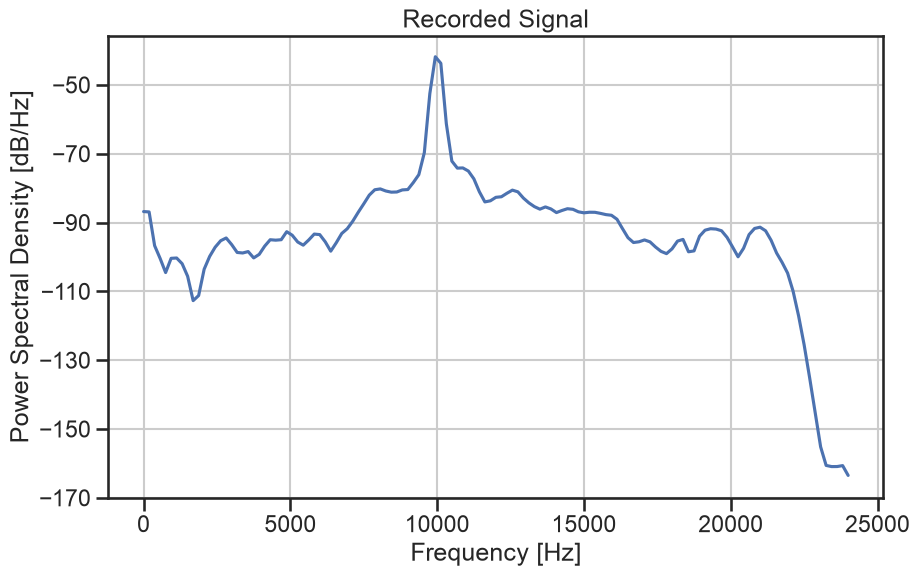

In [ ]:
## look at the PSD ...
plt.psd(recorded_signal[:, 0], Fs=fs)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density [dB/Hz]')
plt.title('Recorded Signal')
plt.show()

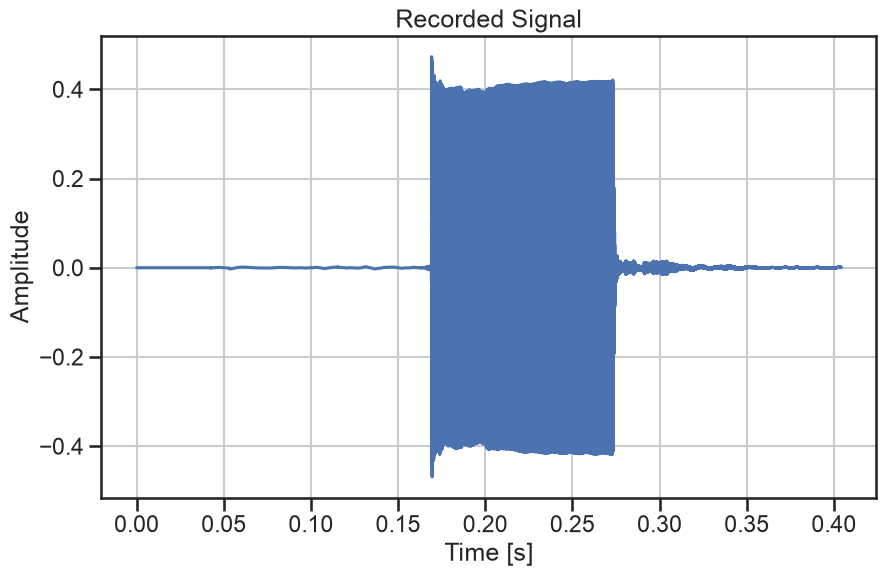

In [ ]:
## and the time-domain signal
plt.plot(np.arange(len(recorded_signal)) / fs, recorded_signal[:, 0])
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Recorded Signal')
plt.grid()
plt.show()